In [1]:
import pandas as pd

In [2]:
raw_data = {"name": ['Bulbasaur', 'Charmander','Squirtle','Caterpie'],
            "evolution": ['Ivysaur','Charmeleon','Wartortle','Metapod'],
            "type": ['grass', 'fire', 'water', 'bug'],
            "hp": [45, 39, 44, 45],
            "pokedex": ['yes', 'no','yes','no']                        
            }

In [3]:
pokemon = pd.DataFrame(raw_data)
pokemon.head()

,name,evolution,type,hp,pokedex
0,Bulbasaur,Ivysaur,grass,45,yes
1,Charmander,Charmeleon,fire,39,no
2,Squirtle,Wartortle,water,44,yes
3,Caterpie,Metapod,bug,45,no


In [4]:
pokemon = pokemon[['name','type','hp','evolution','pokedex']]
pokemon['place'] = ['park','street','lake','forest']
pokemon
pokemon1 = pokemon.copy()

In [5]:
odd_cnt=0;
even_cnt=0
def g(i):
    global odd_cnt;
    global even_cnt;
    print(i)
    if(i%2==0): 
        odd_cnt+=1
        return 3*(odd_cnt)
    else: 
        even_cnt+=1
        return 4*(even_cnt)

In [6]:
# pokemon1['c']=range(len(pokemon['place']))
list1=[]
for i in range(4):
    list1.append((i+1)*5)
pokemon1['times']=list1
pokemon1
# pokemon1['times'] = [(i+1)*5 for i in range(4)]
pokemon1['green'] = [g(i) for i in range(4)]
pokemon1

0
1
2
3


,name,type,hp,evolution,pokedex,place,times,green
0,Bulbasaur,grass,45,Ivysaur,yes,park,5,3
1,Charmander,fire,39,Charmeleon,no,street,10,4
2,Squirtle,water,44,Wartortle,yes,lake,15,6
3,Caterpie,bug,45,Metapod,no,forest,20,8


In [7]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
url = 'https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/09_Time_Series/Apple_Stock/appl_1980_2014.csv'
apple = pd.read_csv(url)
apple.head(1)

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.8,93.92,95.35,65130000,95.35


In [9]:
apple.Date = pd.to_datetime(apple.Date)
apple['Date'].head()

0   2014-07-08
1   2014-07-07
2   2014-07-03
3   2014-07-02
4   2014-07-01
Name: Date, dtype: datetime64[ns]

In [10]:
apple.index.is_unique #index가 중복인 데이터가 없는지 확인

True

In [11]:
apple.sort_index(ascending=True).head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,2014-07-08,96.27,96.80,93.92,95.35,65130000,95.35
1,2014-07-07,94.14,95.99,94.10,95.97,56305400,95.97
2,2014-07-03,93.67,94.10,93.20,94.03,22891800,94.03
3,2014-07-02,93.87,94.06,93.09,93.48,28420900,93.48
4,2014-07-01,93.52,94.07,93.13,93.52,38170200,93.52


In [12]:
apple = apple.set_index('Date')

In [13]:
apple_month = apple.resample('BME').mean()
apple_month.head()

,Open,High,Low,Close,Volume,Adj Close
Date,,,,,,
1980-12-31,30.481538,30.567692,30.443077,30.443077,2.586252e+07,0.473077
1981-01-30,31.754762,31.826667,31.654762,31.654762,7.249867e+06,0.493810
1981-02-27,26.480000,26.572105,26.407895,26.407895,4.231832e+06,0.411053
1981-03-31,24.937727,25.016818,24.836364,24.836364,7.962691e+06,0.387727
1981-04-30,27.286667,27.368095,27.227143,27.227143,6.392000e+06,0.423333


In [14]:
(apple.index.max()- apple.index.min()).days

12261

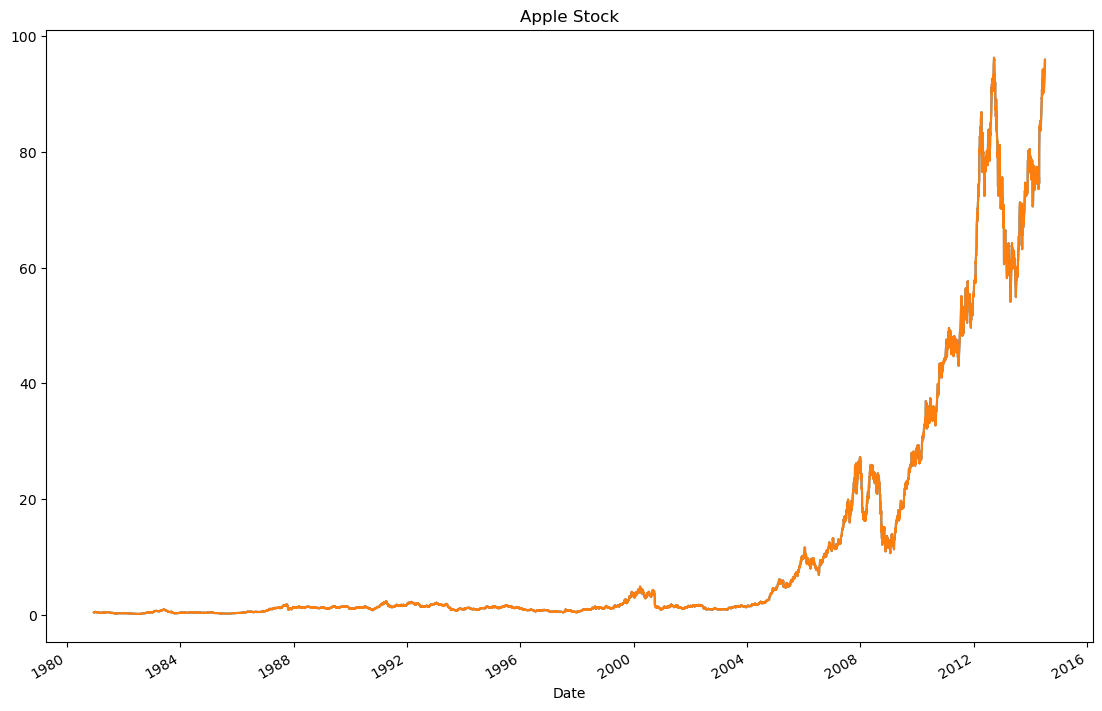

In [16]:
apple_open = apple['Adj Close'].plot(title='Apple Stock')
fig = apple_open.get_figure()
fig.set_size_inches(13.5,9)
plt.show()